

# Step 1: Data Cleaning and Exploration
Before modeling:

1. Inspect missing values and duplicate reviews.
2. Review the distribution of apps, ratings, dates, and review lengths.
3. Define and document which apps will be treated as AI/chatbot-relevant.
4. Retain fields needed for analysis, including review text, app name, rating, date, and likes.
5. Document every major cleaning or filtering decision so the workflow is reproducible.
6. Avoid removing words or phrases that may carry meaning relevant to dependence, attachment, isolation, or frustration.

### Project Summary
In this project, you will use public mental health app review data and natural language processing (NLP) and supervised classification techniques to build a model that classifies user-reported risk themes in app reviews, such as dependence, attachment, isolation, crisis-response frustration, or other concerns.

This project aims to help product, trust and safety, compliance, and app-quality teams identify recurring user-risk signals that may not be visible from star ratings or safety policies alone.

The project focuses on identifying patterns in public user reviews. It is not intended to diagnose users, evaluate clinical effectiveness, or establish that an AI tool caused a particular mental-health outcome.

In [3]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#importing the dataset and looking at a couple rows

df_data = pd.read_csv('../data/MHARD_dataset.csv')
df_data.head(15)



,UID,app_name,rating,date,review,review_cleaned,likes,response_date,response,pred_gpt3.5instruct,pred_gpt3.5turbo,pred_gpt4,pred_gemini1.5flash,pred_gemini1.5pro,pred_llama3.1_8b,pred_llama3.3_70b
0,1,chiku,5,"August 17, 2020",I'm digging it. journaling everything I do dur...,im digging journaling everything day complaint...,30,"August 23, 2020",We have fixed the issue in our latest update (...,4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,2,chiku,4,"December 22, 2020","I really like this app, however, the awesome s...",really like app however awesome smiley graphic...,18,"December 22, 2020",Thank you so much for taking out time to write...,4.0,4.0,4.0,4.0,4.0,4.0,4.0
2,3,chiku,5,"March 02, 2022","I love this. It's so calming, and relaxing, an...",love calming relaxing definitely one favorite ...,62,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0
3,4,chiku,4,"April 27, 2023",This app is really great! Its has many feature...,app really great many feature thing apps pay p...,56,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0
4,5,chiku,4,"April 10, 2023",This app used to be amazing but now whenever I...,app used amazing whenever try make story start...,59,"April 13, 2023",We are really sorry for the inconvenience. We ...,2.0,2.0,2.0,2.0,3.0,3.0,2.0
5,6,chiku,1,"March 03, 2023","Right after i updated, the next time i opened ...",right updated next time opened app previous st...,29,"March 03, 2023","We are sorry that you are facing problems, you...",1.0,1.0,1.0,1.0,1.0,2.0,1.0
6,7,chiku,3,"January 12, 2023",I really love this app. It's really cute. It h...,really love app really cute really cute mood e...,33,NaN,NaN,4.0,3.0,2.0,2.0,3.0,4.0,3.0
7,8,chiku,5,"March 11, 2020",Amazing app. It has functions to follow your m...,amazing app function follow mood draw pictures...,9,"April 07, 2020",Thank you so much for the encouraging words! W...,5.0,5.0,5.0,5.0,5.0,5.0,5.0
8,9,chiku,5,"March 13, 2023","Cute, simple, and aesthetic theme. It's super ...",cute simple aesthetic theme super easy use lov...,8,NaN,NaN,5.0,5.0,5.0,4.0,5.0,5.0,5.0
9,10,chiku,1,"February 19, 2023",I updated the app and It deleted all of my jou...,updated app deleted journal entry year memory ...,7,"February 21, 2023","Hi Haven we are so sorry for the issue, but do...",1.0,1.0,1.0,1.0,1.0,3.0,1.0


In [5]:
#looking at total columns and rows

df_data.shape

(200972, 16)

### Potential Columns to Drop

- We can potentially get rid of the **response_date** and **response** columns because it doesn't seem to be relevant to the project goal of identifying user-risk themes.

- Also we can get rid of the rows that are missing reviews because the customer rating can be entirely irrelevant to any of the risk themes so we can't make any assumptions.

- I'm also unsure if we need to keep any of the model predictions because I'm not sure if it has any correlation to classifying the reviews into any of the risk labels.



In [6]:
#All of the the rows and all of the null values throughout the table

null_rows = df_data.isna().sum()
null_rows

UID                         0
app_name                    0
rating                      0
date                        0
review                     21
review_cleaned            240
likes                       0
response_date          148609
response               148609
pred_gpt3.5instruct       305
pred_gpt3.5turbo          191
pred_gpt4                 501
pred_gemini1.5flash      2403
pred_gemini1.5pro          54
pred_llama3.1_8b        10429
pred_llama3.3_70b         885
dtype: int64

- The **review_cleaned** column is kinda confusing. It has the same information but it lacks a lot of the grammar and cuts out words so sentences and thoughts are really hard to separate and understand properly.

In [7]:
print('review: ',df_data['review'][1],'\n')
print('review_cleaned: ',df_data['review_cleaned'][1])

review:  I really like this app, however, the awesome smiley graphic is a bit unnerving. All of the other ones are cute, but the awesome guy really freaks me out and I think it should be redesigned. I've narrowed down a handful of apps to 2 between this and reflectly and I like the setup of Chiku more in terms of the layout of journals and ability to favorite, but I like the tracking tools of reflectly, their icons, ability to add your own icons, and modern minimalist design better. I am honestly so torn 

review_cleaned:  really like app however awesome smiley graphic bit unnerving one cute awesome guy really freak think redesigned ive narrowed handful apps reflectly like setup chiku term layout journal ability favorite like tracking tool reflectly icon ability add icon modern minimalist design better honestly torn


In [8]:
#No duplicated rows

df_data.duplicated().sum()

np.int64(0)

### All of the unique app names in the dataset 

In [9]:


unique_apps = (df_data['app_name'].unique())
unique_apps


<ArrowStringArray>
[           'chiku',        'intellect',              'vos',
         'talklife',         'besthelp',         'mindease',
   'mypossibleself',        'moodspace',          'happify',
           'roubit',         'sanvello',      'anxietytest',
        'unwinding',         'cerebral',  'minddiagnostics',
        'dailybean',        'talkspace',   'teencounseling',
       'breathball',        'headspace',      'twentyninek',
        'sevencups',           'evolve',          'clarity',
             'calm',           'regain',            'norbu',
    'anxietyrelief',         'blockapp',              'iam',
         'fabulous',         'welltory',            'rootd',
         'constant',            'finch',        'mindshift',
            'voice',         'bearable',           'youper',
               'up',        'reflectly',             'heyy',
        'moodpress',        'stoppanic',     'healthyminds',
            'amaha',           'breeze', 'digitalwellbeing',
     

### AVG App Rating and App Review Count

In [10]:
app_review_count = {}
app_avg_review = {}

for i in unique_apps:
    app_rows = (df_data[df_data['app_name']==i])
    print(i," count: ",app_rows.shape[0])
    app_review_count[i] = app_rows.shape[0]
    print(i, " mean: ", (app_rows['rating'].mean()),'\n')
    app_avg_review[i] = app_rows['rating'].mean()


chiku  count:  501
chiku  mean:  4.570858283433134 

intellect  count:  16045
intellect  mean:  4.703708320349018 

vos  count:  551
vos  mean:  3.778584392014519 

talklife  count:  4575
talklife  mean:  3.8926775956284154 

besthelp  count:  238
besthelp  mean:  2.8949579831932772 

mindease  count:  187
mindease  mean:  4.224598930481283 

mypossibleself  count:  726
mypossibleself  mean:  4.387052341597796 

moodspace  count:  1009
moodspace  mean:  4.535183349851338 

happify  count:  932
happify  mean:  2.915236051502146 

roubit  count:  164
roubit  mean:  3.75 

sanvello  count:  6563
sanvello  mean:  4.453451165625476 

anxietytest  count:  32
anxietytest  mean:  3.625 

unwinding  count:  325
unwinding  mean:  4.483076923076923 

cerebral  count:  1980
cerebral  mean:  2.6166666666666667 

minddiagnostics  count:  336
minddiagnostics  mean:  4.095238095238095 

dailybean  count:  2304
dailybean  mean:  4.475694444444445 

talkspace  count:  2374
talkspace  mean:  2.4422914911

### AVG/Median Review length

The difference in overall length for the reviews and cleaned reviews

In [11]:
#this is for the normal reviews

print(df_data['review'].str.len().describe())
print('median: ',df_data['review'].str.len().median())

count    200951.000000
mean        165.122965
std         138.703401
min           1.000000
25%          59.000000
50%         123.000000
75%         231.000000
max        3649.000000
Name: review, dtype: float64
median:  123.0


In [12]:
#this is for the cleaned reviews

print(df_data['review_cleaned'].str.len().describe())
print('median: ',df_data['review_cleaned'].str.len().median())

count    200732.000000
mean        101.970294
std          85.272536
min           1.000000
25%          38.000000
50%          76.000000
75%         142.000000
max        2338.000000
Name: review_cleaned, dtype: float64
median:  76.0


### Reviews Posted the Same Dates

In [13]:
unique_dates = df_data['date'].unique()
for i in unique_dates:
    print(i, df_data[df_data['date']==i][['app_name', 'review']])


August 17, 2020         app_name                                             review
0          chiku  I'm digging it. journaling everything I do dur...
288        chiku  I love the app if you wants a diary this is be...
414        chiku                    It has been very helpful so far
472        chiku                                        It good app
17305   talklife  The app has become very glitchy. Cant open com...
...          ...                                                ...
191702    woebot  Absolutely WONDERFUL and it does help. I actua...
192056    woebot  Good app, but it keeps asking me to rate it ev...
193054    woebot  I just tried it for the first time and think i...
196429    pixels  It's one of the only apps I consistently use o...
197131    pixels  Honestly my favourite app that I own. It's ver...

[113 rows x 2 columns]
December 22, 2020          app_name                                             review
1           chiku  I really like this app, however, the a

### Reviews with the Most Likes

In [14]:
df_sorted_likes = df_data.sort_values(by='likes', ascending=False)
df_sorted_likes[['app_name','review','likes']]

,app_name,review,likes
72449,calm,"As a ""free"" app I give this 1 star. But I do l...",2413
133381,digitalwellbeing,The newer version seems to he filled with full...,2021
69341,calm,This is a great app but it lost its mission & ...,1894
68581,calm,Upon initial opening of the app it FORCES you ...,1793
66533,calm,Most things are locked behind a pay wall. They...,1611
...,...,...,...
83700,iam,it a wonderful reminder of what's already with...,0
83702,iam,Amazing amazing amazing 🌹,0
83703,iam,I amissuch a good app and helps confidence,0
83704,iam,I love it makes My days brighter,0


### Visualizing the app data distruibution

NameError: name 'apps' is not defined

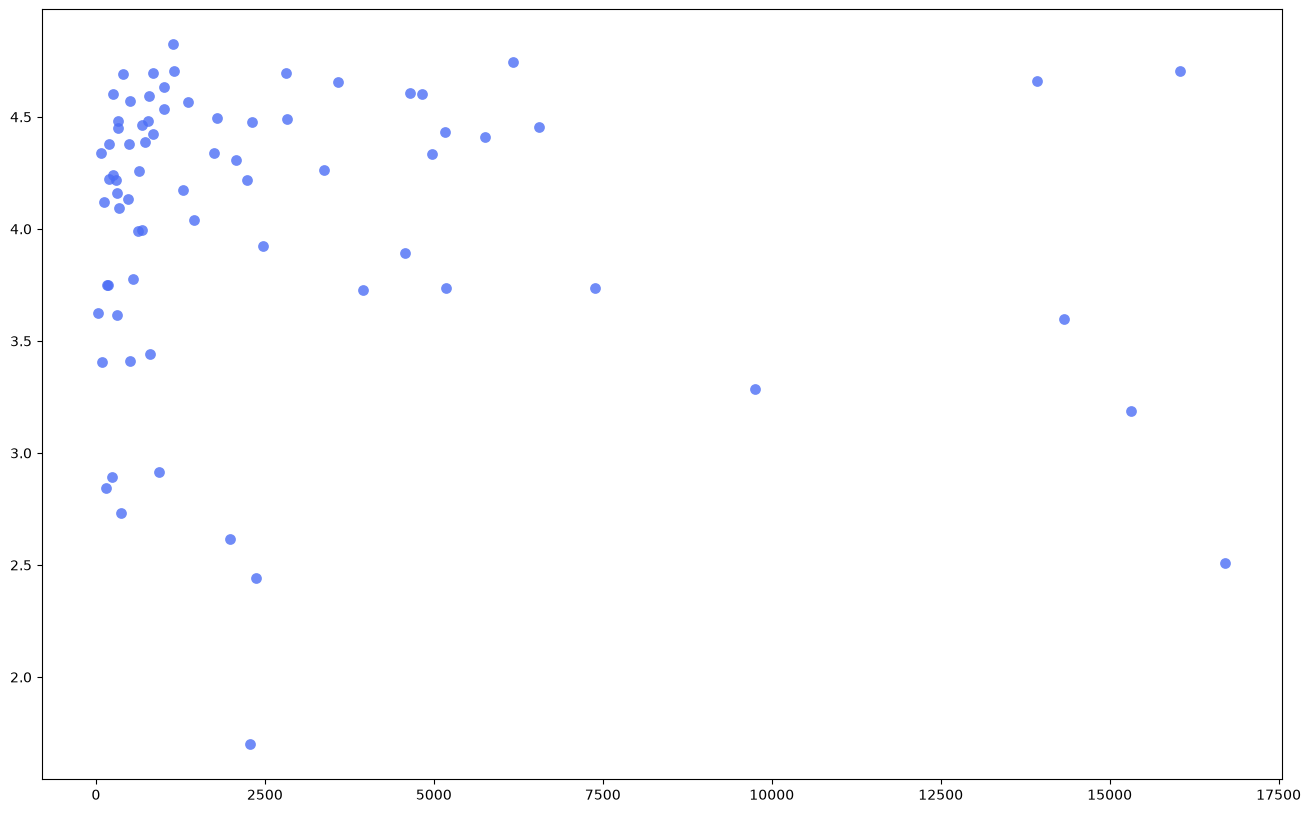

In [16]:
#Scatter plot: review count (x, log scale) vs. average rating (y), labeled with each app's name.
#app_review_count / app_avg_review are dicts keyed by app_name, built from the same loop over
#unique_apps, so their keys are in the same order and can be safely zipped together.

x = [app_review_count[a] for a in unique_apps]
y = [app_avg_review[a] for a in unique_apps]

fig, ax = plt.subplots(figsize=(16, 10))

ax.scatter(x, y,
           s=60, alpha=0.8, linewidths=0,
           color='#4C6EF5')

for app, xi, yi in zip(apps, x, y):
    ax.annotate(app, (xi, yi), fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Number of reviews (log scale)')
ax.set_ylabel('Average rating')
ax.set_ylim(0.8, 5.2)
ax.set_title('App rating vs. review volume')

ax.grid(axis='y', color='#E5E7EB', linewidth=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
#The cleaned reviews and reviews can be used interchangeably

potential_dataset = df_data[['app_name', 'rating','review', 'likes']]
potential_dataset 

,app_name,rating,review,likes
0,chiku,5,I'm digging it. journaling everything I do dur...,30
1,chiku,4,"I really like this app, however, the awesome s...",18
2,chiku,5,"I love this. It's so calming, and relaxing, an...",62
3,chiku,4,This app is really great! Its has many feature...,56
4,chiku,4,This app used to be amazing but now whenever I...,59
...,...,...,...,...
200967,pixels,3,Please add option to add our own emotions.,1
200968,pixels,5,Nice. Great way to keep track of stuff,0
200969,pixels,1,For some reason even when not using the app it...,1
200970,pixels,5,"Simple, and easy to keep track",0


### Filtering Conversational-Agent Apps by Agent Start Date

Only keep reviews written **on or after** the date each app had a conversational agent. Earlier reviews are about a different product (e.g. Happify before its Anna AI coach), so they would add noise to the risk-theme labels.

| App | Agent start used as cutoff | Source note |
|---|---|---|
| wysa | 2016-10-01 | App launched late 2016 as a chatbot |
| woebot | 2017-06-01 | Facebook Messenger June 2017; iOS app 25 Jan 2018 |
| sevencups | 2014-10-01 | Noni bot since Oct 2014 (open "free chat" from ~Sept 2017) |
| healthily | 2015-11-01 | Chat-based assistant in the app since beta, Nov 2015 |
| happify | 2020-11-19 | Anna AI coach live by 19 Nov 2020 (latest possible start) |
| youper | 2017-01-01 | Switched to a chatbot c. 2017 (exact date not found) |
| amaha | 2020-04-01 | "Bot-based check-ins" by Apr 2020; Allie named by Oct 2021 |
| voidpet | 2023-04-02 | Released 9 Feb 2023; chat confirmed live by 2 Apr 2023 |

Where the start date is uncertain, the cutoff uses the earliest date we can **confirm** the agent was live, so every kept review is definitely about the chatbot version. In practice only healthily, happify, amaha and voidpet lose reviews: the MHARD reviews for the other four apps all start after their cutoff.


In [17]:
#Date each app is confirmed to have a conversational agent

agent_start_dates = {
    'wysa': '2016-10-01',
    'woebot': '2017-06-01',
    'sevencups': '2014-10-01',
    'healthily': '2015-11-01',
    'happify': '2020-11-19',
    'youper': '2017-01-01',
    'amaha': '2020-04-01',
    'voidpet': '2023-04-02',
}
agent_start_dates = {app: pd.Timestamp(d) for app, d in agent_start_dates.items()}

df_data['date_parsed'] = pd.to_datetime(df_data['date'], format='%B %d, %Y')


In [18]:
#Keep only the chatbot apps, then only reviews on or after each app's agent start date

df_agent = df_data[df_data['app_name'].isin(agent_start_dates.keys())].copy()
df_agent['agent_start_date'] = df_agent['app_name'].map(agent_start_dates)
df_agent_filtered = df_agent[df_agent['date_parsed'] >= df_agent['agent_start_date']]

summary = pd.DataFrame({
    'agent_start_date': pd.Series(agent_start_dates).dt.date,
    'reviews_before': df_agent['app_name'].value_counts(),
    'reviews_kept': df_agent_filtered['app_name'].value_counts(),
    'first_review_kept': df_agent_filtered.groupby('app_name')['date_parsed'].min().dt.date,
})
summary['reviews_dropped'] = summary['reviews_before'] - summary['reviews_kept']
summary


,agent_start_date,reviews_before,reviews_kept,first_review_kept,reviews_dropped
amaha,2020-04-01,5168,4398,2020-04-03,770
happify,2020-11-19,932,204,2020-11-24,728
healthily,2015-11-01,1451,1191,2015-11-01,260
sevencups,2014-10-01,7384,7384,2014-12-26,0
voidpet,2023-04-02,1013,428,2023-04-02,585
woebot,2017-06-01,4832,4832,2018-03-11,0
wysa,2016-10-01,1791,1791,2018-09-13,0
youper,2017-01-01,3382,3382,2018-09-12,0


In [20]:
#Save the filtered chatbot-review dataset

agent_dataset = df_agent_filtered[['UID', 'app_name', 'rating', 'date', 'review', 'likes']]
agent_dataset.to_csv('../data/agent_reviews_filtered.csv', index=False)
agent_dataset.shape
agent_dataset


,UID,app_name,rating,date,review,likes
23834,23835,happify,3,"February 21, 2021","I generally think this is a great app, with a ...",84
23839,23840,happify,1,"May 22, 2023",My health insurance (Cigna) says it provides a...,6
23840,23841,happify,2,"April 29, 2023","it could be a good app, but it is just way too...",2
23841,23842,happify,5,"May 15, 2023",It's awesome for helping me cope with stress a...,1
23843,23844,happify,1,"June 05, 2023",Tried logging in with mycigna and it won't acc...,0
...,...,...,...,...,...,...
195809,195810,wysa,5,"April 26, 2019",I've been going through a really tough time re...,4
195810,195811,wysa,2,"October 09, 2019",this is ridiculously getting too much of a mon...,1
195811,195812,wysa,5,"September 25, 2020",Incredible This app helps so much with anxiety...,3
195812,195813,wysa,5,"July 22, 2021",a great addition to my practice of spiritual d...,28
